**Train Model**

In [1]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
from torch.utils.data import random_split, DataLoader, ConcatDataset
import matplotlib.pyplot as plt

torch.manual_seed(32)

##### 1.0 Data Preparation

In [2]:
# Define data path
t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')

# Define dataset 
t1_dataset = MRIDataset(t1_npz_dir, 1)
t2_dataset = MRIDataset(t2_npz_dir, 2)

t1_dataset.files = t1_dataset.files[:300]
t2_dataset.files = t2_dataset.files[:300]

# Split sizes 
min_size = min(len(t1_dataset), len(t2_dataset))
train_size = int(0.7 * min_size)
val_size = int(0.15 * min_size)

# Create train, val, and test sets separately for T1 and T2
t1_train, t1_val, t1_test = random_split(t1_dataset, [train_size, val_size, len(t1_dataset) - train_size - val_size])
t2_train, t2_val, t2_test = random_split(t2_dataset, [train_size, val_size, len(t2_dataset) - train_size - val_size])

# Merge T1 and T2 to get final datasets
train_dataset = ConcatDataset([t1_train, t2_train])
val_dataset = ConcatDataset([t1_val, t2_val])
test_dataset = ConcatDataset([t1_test, t2_test])

# Create DataLoaders
batch_size = 2
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
<>:2: SyntaxWarning: invalid escape sequence '\I'
<>:3: SyntaxWarning: invalid escape sequence '\I'
C:\Users\PC\AppData\Local\Temp\ipykernel_3124\3183949832.py:2: SyntaxWarning: invalid escape sequence '\I'
  t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
C:\Users\PC\AppData\Local\Temp\ipykernel_3124\3183949832.py:3: SyntaxWarning: invalid escape sequence '\I'
  t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')


##### 2.0 Setting Up Hyperparameters

In [3]:
# Custom MSE loss function with background exclusion
def masked_mse_loss(reconstructed, target, mask):
    masked_diff = (reconstructed - target) * mask 
    loss = torch.sum(masked_diff ** 2) / torch.sum(mask) 
    return loss

In [4]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)

# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Define number of epochs
n_epochs = 10

##### 3.0 Model Training

In [5]:
# Training loop
training_losses = []
validation_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0

    for ground_truth, noisy_image, mask, modality in train_loader:
        ground_truth, noisy_image, mask, modality = ground_truth.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), mask.to(device, non_blocking=True), modality.to(device, non_blocking=True)

        optimizer.zero_grad()
        output = model(noisy_image, modality)
        loss = masked_mse_loss(output, ground_truth, mask)
        epoch_loss += loss.item()
        loss.backward()
        optimizer.step()

    torch.save(model.state_dict(), f'model_epoch_{epoch+1}.pth')
    avg_train_loss = epoch_loss / len(train_loader)
    training_losses.append(avg_train_loss)
    
    # Run Validation
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0

    with torch.no_grad():  
        for ground_truth, noisy_image, mask, modality in val_loader:
            ground_truth, noisy_image, mask, modality = ground_truth.to(device, non_blocking=True), noisy_image.to(device, non_blocking=True), mask.to(device), modality.to(device, non_blocking=True)
            output = model(noisy_image, modality)
            loss = masked_mse_loss(output, ground_truth, mask)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    validation_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{n_epochs}] - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f}")

Epoch [1/10] - Train Loss: 0.038557 - Val Loss: 0.012558
Epoch [2/10] - Train Loss: 0.010597 - Val Loss: 0.010149
Epoch [3/10] - Train Loss: 0.008782 - Val Loss: 0.008479
Epoch [4/10] - Train Loss: 0.007812 - Val Loss: 0.007692
Epoch [5/10] - Train Loss: 0.007041 - Val Loss: 0.006871
Epoch [6/10] - Train Loss: 0.006884 - Val Loss: 0.006334
Epoch [7/10] - Train Loss: 0.006566 - Val Loss: 0.006202
Epoch [8/10] - Train Loss: 0.006127 - Val Loss: 0.005791
Epoch [9/10] - Train Loss: 0.005892 - Val Loss: 0.006017
Epoch [10/10] - Train Loss: 0.005837 - Val Loss: 0.005519


In [6]:
# Save model 
torch.save(model.state_dict(), "full_model_weights.pth") 

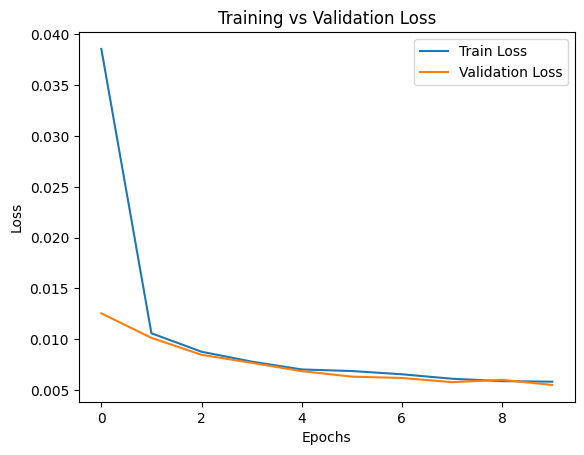

In [7]:
# Visualise training and validation losses
plt.plot(training_losses, label="Train Loss")
plt.plot(validation_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()